In [2]:
# ======================================================================
# Importação das Bibliotecas Necessárias
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import yfinance as yf

In [3]:
def max_drawdown(equity_curve):
    peak = np.maximum.accumulate(equity_curve)
    dd = (equity_curve / peak) - 1.0
    return float(dd.min())


In [4]:
def sharpe_simple(pnls, freq=252):
    std = pnls.std()
    if std == 0: 
        return 0.0
    return float((pnls.mean() / std) * np.sqrt(freq))


In [5]:
def pos_from_action(a):     
    return {0: 0, 1: 1, 2: -1}[a]


In [6]:
def pos_index_from_pos(p):   
    return {0: 0, 1: 1, -1: 2}[p]


In [7]:
def state_index(position, m_bin):
    return pos_index_from_pos(position) * N_MOMBINS + int(m_bin)


In [8]:
def pnl_step(ret, pos_prev, pos_now, tx):
    return pos_now * ret - tx * abs(pos_now - pos_prev)


In [9]:
def avaliar_politica_gulosa(Q, rets, mom_bins, tx_custo):
    pos = 0
    equity = 1.0
    eq_series = [equity]
    pnl_list = []

    for t in range(1, len(rets) - 1):
        s = state_index(pos, mom_bins[t])
        a = int(np.argmax(Q[s]))
        new_pos = pos_from_action(a)

        r = pnl_step(rets[t], pos, new_pos, tx_custo)
        pnl_list.append(r)

        equity *= (1.0 + r)
        eq_series.append(equity)
        pos = new_pos

    return np.array(pnl_list, dtype=float), np.array(eq_series, dtype=float)


In [10]:
# ======================================================================
# Definição das Sementes
# ======================================================================
SEMENTE = 1965
random.seed(SEMENTE)
np.random.seed(SEMENTE)


In [11]:
# ======================================================================
# Definição das Categorias
# ======================================================================
TICKER = "PETR4.SA"      # Ex.: "PETR4.SA", "VALE3.SA", "AAPL", "MSFT"
START  = "2016-01-01"
END    = "2024-12-31"

LOOKBACK_MOM = 10        # janela do momentum
N_BINS = 5               # quantização do momentum
TX_CUSTO = 0.0005        # 0.05% por mudança de posição
SPLIT_DATE = "2022-01-01" # separa treinamento/avaliação

EPISODIOS = 40           # nº de passagens pela amostra de treino
ALPHA = 0.1              # taxa de aprendizagem
GAMMA = 0.99             # desconto
EPSILON_INI = 1.0        # exploração inicial
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.999    # decaimento por passo (pode mover para fim do episódio)



In [12]:
# ======================================================================
# Dados reais (yfinance)
# ======================================================================
df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if df.empty:
    raise ValueError("Sem dados. Verifique o ticker/intervalo/datas.")

df = df[['Close']].dropna().copy()
df['ret'] = df['Close'].pct_change()
df['mom'] = df['Close'].pct_change(LOOKBACK_MOM)  # momentum simples
df.dropna(inplace=True)

# Split train/test
df_train = df.loc[:SPLIT_DATE].copy()
df_test  = df.loc[SPLIT_DATE:].copy()
if len(df_test) < 2 or len(df_train) < 2:
    raise ValueError("Ajuste as datas de split; poucos dados em train ou test.")

# Bins de momentum APENAS no treino (evita vazamento)
edges = np.quantile(df_train['mom'], np.linspace(0, 1, N_BINS + 1))
edges = np.unique(edges)  # garantir estritamente crescentes
if len(edges) < 3:  # caso extremo: pouca variação → força 3 bins
    edges = np.array([df_train['mom'].min(), df_train['mom'].median(), df_train['mom'].max()])

def bin_mom(x):
    inner = edges[1:-1]    # pontos internos (np.digitize define faixas)
    return np.digitize(x, inner, right=False)  # retorna 0..(len(edges)-2)

df_train['mom_bin'] = df_train['mom'].apply(bin_mom)
df_test['mom_bin']  = df_test['mom'].apply(bin_mom)


In [13]:
# ======================================================================
# Espaço de estados/ações
# ======================================================================
# posição: 0=flat, 1=long, 2=short
N_POS = 3
N_ACT = 3   # 0 -> ir/ficar flat; 1 -> ir/ficar long; 2 -> ir/ficar short
N_MOMBINS = len(edges) - 1
N_STATES = N_POS * N_MOMBINS


In [14]:
# ======================================================================
# Vetores de treino/teste (numpy)
# ======================================================================
train_close = df_train['Close'].values
train_ret   = df_train['ret'].values
train_bin   = df_train['mom_bin'].values

test_close  = df_test['Close'].values
test_ret    = df_test['ret'].values
test_bin    = df_test['mom_bin'].values


In [15]:
# ======================================================================
# Q-Table e treinamento
# ======================================================================
Q = np.zeros((N_STATES, N_ACT), dtype=np.float32)

epsilon = EPSILON_INI
rewards_per_ep = []
eps_hist = []

for ep in range(EPISODIOS):
    pos = 0  # começa flat
    rew_ep = 0.0

    # cada episódio percorre a série de treino: t=1..len-1
    for t in range(1, len(train_close) - 1):
        s  = state_index(pos, train_bin[t])

        # ε-greedy
        if random.random() < epsilon:
            a = random.randrange(N_ACT)
        else:
            a = int(np.argmax(Q[s] + np.random.rand(N_ACT) / 1e6))  # desempate

        new_pos = pos_from_action(a)
        r = pnl_step(train_ret[t], pos, new_pos, TX_CUSTO)
        s2 = state_index(new_pos, train_bin[t + 1])

        # Q-learning update
        Q[s, a] += ALPHA * (r + GAMMA * np.max(Q[s2]) - Q[s, a])

        pos = new_pos
        rew_ep += r

        # decaimento do epsilon por passo (se quiser por episódio, mova para fora do loop)
        if epsilon > EPSILON_MIN:
            epsilon *= EPSILON_DECAY

    rewards_per_ep.append(rew_ep)
    eps_hist.append(epsilon)
    if (ep + 1) % 5 == 0:
        print(f"Episódio {ep+1}/{EPISODIOS} | Recompensa treino: {rew_ep:.6f} | ε: {epsilon:.4f}")

print("\nTreinamento concluído.")

Episódio 5/40 | Recompensa treino: 10.295028 | ε: 0.0500
Episódio 10/40 | Recompensa treino: 10.383871 | ε: 0.0500
Episódio 15/40 | Recompensa treino: 9.881320 | ε: 0.0500
Episódio 20/40 | Recompensa treino: 10.856828 | ε: 0.0500
Episódio 25/40 | Recompensa treino: 8.794593 | ε: 0.0500
Episódio 30/40 | Recompensa treino: 7.773811 | ε: 0.0500
Episódio 35/40 | Recompensa treino: 10.367794 | ε: 0.0500
Episódio 40/40 | Recompensa treino: 10.035199 | ε: 0.0500

Treinamento concluído.


In [16]:
pnls_test, equity_test = avaliar_politica_gulosa(Q, test_ret, test_bin, TX_CUSTO)

# Buy & Hold na janela de teste (normalizando no início da janela de teste)
eq_bh_test = (test_close / test_close[0]).astype(float).reshape(-1)

# Valores escalares para impressão
ql_last = float(np.ravel(equity_test)[-1])
bh_last = float(np.ravel(eq_bh_test)[-1])

print(f"\n=== Avaliação (TEST) – {TICKER} ===")
print(f"Equity final Q-Learning: {ql_last:.4f}x do capital inicial  ({(ql_last-1)*100:.2f}%)")
print(f"Equity final Buy&Hold :  {bh_last:.4f}x do capital inicial  ({(bh_last-1)*100:.2f}%)")

mdd_q  = max_drawdown(equity_test)
sh_q   = sharpe_simple(pnls_test)
mdd_bh = max_drawdown(eq_bh_test)
pnls_bh = eq_bh_test[1:] / eq_bh_test[:-1] - 1.0
sh_bh   = sharpe_simple(pnls_bh)

print(f"Max Drawdown Q-Learning: {mdd_q*100:.2f}%  | Sharpe Q-Learning: {sh_q:.2f}")
print(f"Max Drawdown Buy&Hold : {mdd_bh*100:.2f}% | Sharpe Buy&Hold : {sh_bh:.2f}")




=== Avaliação (TEST) – PETR4.SA ===
Equity final Q-Learning: 14.7095x do capital inicial  (1370.95%)
Equity final Buy&Hold :  3.1618x do capital inicial  (216.18%)
Max Drawdown Q-Learning: -24.81%  | Sharpe Q-Learning: 3.07
Max Drawdown Buy&Hold : -39.10% | Sharpe Buy&Hold : 1.33


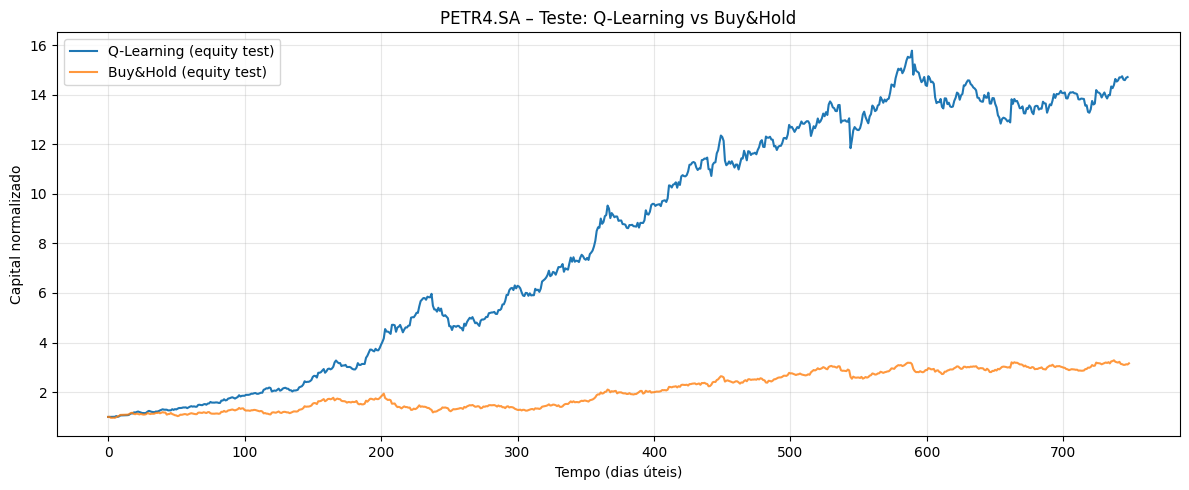

In [17]:
# -------------------------
# 6) Gráficos
# -------------------------
plt.figure(figsize=(12,5))
plt.plot(equity_test, label="Q-Learning (equity test)")
plt.plot(eq_bh_test, label="Buy&Hold (equity test)", alpha=0.8)
plt.title(f"{TICKER} – Teste: Q-Learning vs Buy&Hold")
plt.xlabel("Tempo (dias úteis)"); plt.ylabel("Capital normalizado")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()



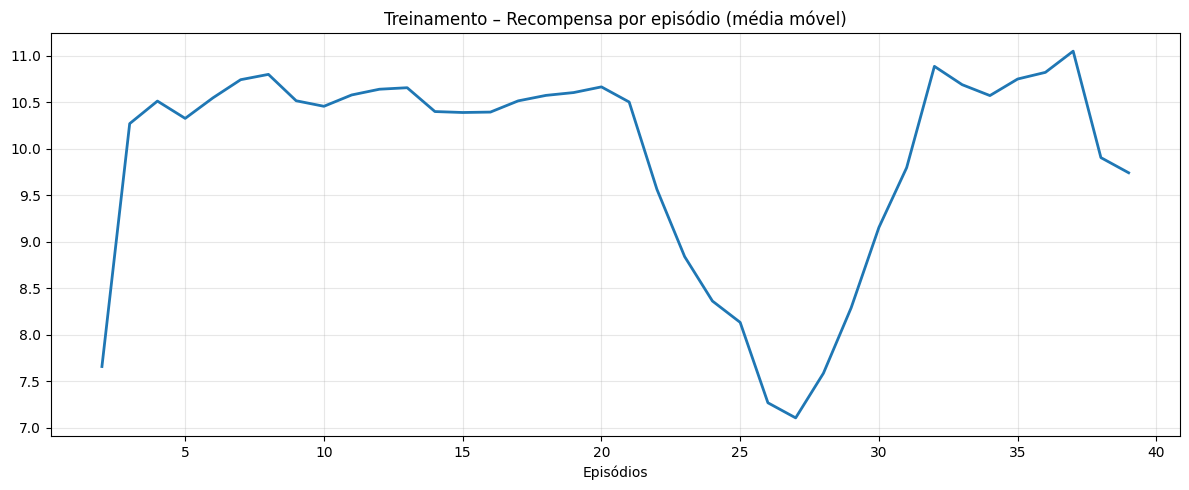

In [18]:
plt.figure(figsize=(12,5))
rm = pd.Series(rewards_per_ep, dtype=float).rolling(3).mean()
plt.plot(rm, lw=2)
plt.title("Treinamento – Recompensa por episódio (média móvel)")
plt.xlabel("Episódios"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()





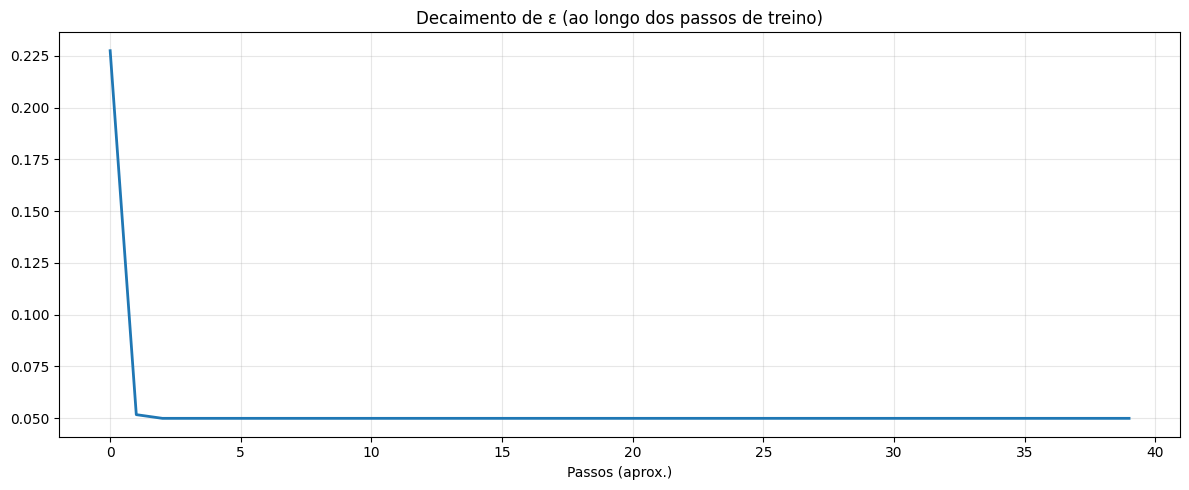

In [19]:
plt.figure(figsize=(12,5))
plt.plot(eps_hist, lw=2)
plt.title("Decaimento de ε (ao longo dos passos de treino)")
plt.xlabel("Passos (aprox.)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

=== Métricas – Teste ===
Q-Learning -> Max Drawdown: -24.81% | Sharpe: 3.07
Buy&Hold   -> Max Drawdown: -39.10% | Sharpe: 1.33


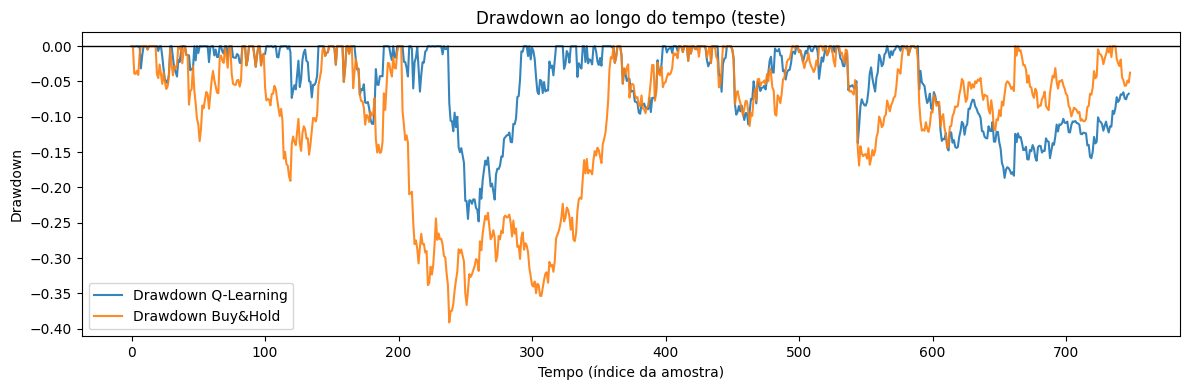

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Funções de métricas
# ---------------------------------------------------------
def returns_from_equity(equity: pd.Series | np.ndarray) -> pd.Series:
    """Retornos simples (t / t-1 - 1) a partir da curva de capital."""
    s = pd.Series(np.asarray(equity), dtype=float).dropna()
    rets = s.pct_change().dropna()
    return rets

def sharpe_ratio(equity, rf=0.0, periods_per_year=252):
    """
    Sharpe anualizado. rf pode ser taxa diária (mesma base dos retornos) ou 0.
    """
    rets = returns_from_equity(equity)
    # excesso de retorno (assumindo rf na mesma frequência)
    excess = rets - rf
    vol = excess.std(ddof=1)
    if vol == 0 or np.isnan(vol):
        return np.nan
    sr = np.sqrt(periods_per_year) * excess.mean() / vol
    return sr

def max_drawdown(equity):
    """
    Max drawdown (valor negativo). Também retorna a série de drawdowns.
    """
    s = pd.Series(np.asarray(equity), dtype=float).dropna()
    rolling_peak = s.cummax()
    dd = s / rolling_peak - 1.0
    mdd = dd.min()  # valor mais negativo
    return float(mdd), dd

# ---------------------------------------------------------
# Exemplo de uso com as SUAS variáveis:
#   equity_test  -> curva do Q-Learning (capital normalizado)
#   eq_bh_test   -> curva do Buy&Hold  (capital normalizado)
# ---------------------------------------------------------
# Se estiverem como listas/arrays, tudo bem; se for DataFrame, selecione a coluna.

# Métricas Q-Learning
mdd_q, dd_curve_q = max_drawdown(equity_test)
sharpe_q = sharpe_ratio(equity_test, rf=0.0, periods_per_year=252)

# Métricas Buy&Hold
mdd_bh, dd_curve_bh = max_drawdown(eq_bh_test)
sharpe_bh = sharpe_ratio(eq_bh_test, rf=0.0, periods_per_year=252)

print("=== Métricas – Teste ===")
print(f"Q-Learning -> Max Drawdown: {mdd_q:.2%} | Sharpe: {sharpe_q:.2f}")
print(f"Buy&Hold   -> Max Drawdown: {mdd_bh:.2%} | Sharpe: {sharpe_bh:.2f}")

# ---------------------------------------------------------
# (Opcional) Plot das curvas de Drawdown
# ---------------------------------------------------------
plt.figure(figsize=(12,4))
plt.plot(dd_curve_q.values, label="Drawdown Q-Learning", alpha=0.9)
plt.plot(dd_curve_bh.values, label="Drawdown Buy&Hold", alpha=0.9)
plt.axhline(0, color='k', lw=1)
plt.title("Drawdown ao longo do tempo (teste)")
plt.ylabel("Drawdown")
plt.xlabel("Tempo (índice da amostra)")
plt.legend()
plt.tight_layout()
plt.show()


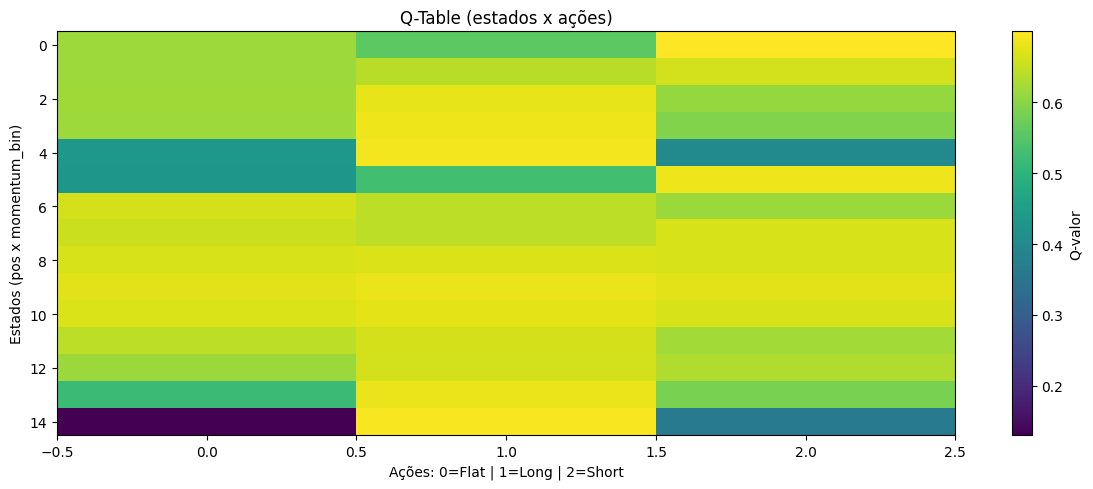

In [19]:
# Heatmap simples da Q-table (matplotlib puro)
plt.figure(figsize=(12,5))
plt.imshow(Q, aspect='auto', cmap='viridis')
plt.colorbar(label="Q-valor")
plt.title("Q-Table (estados x ações)")
plt.xlabel("Ações: 0=Flat | 1=Long | 2=Short")
plt.ylabel("Estados (pos x momentum_bin)")
plt.tight_layout(); plt.show()

In [20]:
# ======================================================================
# FIM DO PROGRAMA
# ======================================================================